
# Denoising Diffusion Probabilistic Models (DDPM) from Scratch
**A minimal implementation, following Ho et al. 2020**

We implement:
- The **forward (diffusion) process**: Eq. (2), (4)
- The **simplified training objective**: Eq. (14), Algorithm 1
- The **reverse (sampling) process**: Algorithm 2
- A small **U-Net** with a sinusoidal timestep embedding (Section 4, Appendix B)

Dataset: **Fashion-MNIST** (28x28 grayscale)

Disclaimer:
I am not implementing any of these: EMA, learned variances, attention blocks, multi-GPU, or any of the scaling tricks in the paper's appendix. Just the core implementation.


In [1]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

import torch

## 1. Setup

In [2]:
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import math

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda



## 2. Data
The paper (Section 3.3) scales image data from integers in $\{0,...,255\}$ linearly to
$[-1, 1]$, so that the network always sees inputs on the same scale as the standard
normal prior $p(\mathbf{x}_T)$. We do the same here.


In [3]:
IMG_SIZE = 28 # 28x28
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda t: (t * 2) - 1),
])
train_dataset = datasets.FashionMNIST(root = "./data", train = True, download = True, transform = transform)

BATCH_SIZE = 128
train_loader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle = True, drop_last = True)

x, _ = next(iter(train_loader))
print("Batch Shape: ", x.shape, "Min: ", x.min().item(), "Max: ", x.max().item())


100%|██████████| 26.4M/26.4M [00:02<00:00, 10.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 163kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.15MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.9MB/s]

Batch Shape:  torch.Size([128, 1, 28, 28]) Min:  -1.0 Max:  1.0


## 2. The Forward (Noising) Process

From the paper:

$$q(\mathbf{x}_t \mid \mathbf{x}_{t-1}) := \mathcal{N}(\mathbf{x}_t; \sqrt{1-\beta_t}\,\mathbf{x}_{t-1}, \beta_t \mathbf{I}) \qquad \text{(Eq. 2)}$$

The key trick (Eq. 4) is that we don't have to add noise step-by-step $T$ times, instead we can jump straight from $\mathbf{x}_0$ to any $\mathbf{x}_t$ in a closed form:

$$q(\mathbf{x}_t \mid \mathbf{x}_0) = \mathcal{N}(\mathbf{x}_t; \sqrt{\bar\alpha_t}\,\mathbf{x}_0, (1-\bar\alpha_t)\mathbf{I}) \qquad \text{(Eq. 4)}$$

where $\alpha_t := 1 - \beta_t$ and $\bar\alpha_t := \prod_{s=1}^t \alpha_s$.

This means: pick a random $\epsilon \sim \mathcal{N}(0, I)$, and

$$\mathbf{x}_t(\mathbf{x}_0, \epsilon) = \sqrt{\bar\alpha_t}\,\mathbf{x}_0 + \sqrt{1-\bar\alpha_t}\,\epsilon$$


We use the paper's linear schedule: $\beta_1 = 10^{-4} \to \beta_T = 0.02$, with $T=1000$
(Section 4).

We'll keep $T=1000$ since it's cheap on small images.


In [4]:
T = 1000

beta_start = 1e-4
beta_end = 0.02
betas = torch.linspace(beta_start, beta_end, T, dtype=torch.float32)

alphas = 1.0 - betas # alpha_t
alphas_cumprod = alphas.cumprod(dim = 0) #alpha_bar_t
alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value = 1.0)

sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)

betas = betas.to(device)
alphas = alphas.to(device)

alphas_cumprod = alphas_cumprod.to(device)
alphas_cumprod_prev = alphas_cumprod_prev.to(device)
sqrt_alphas_cumprod = sqrt_alphas_cumprod.to(device)

sqrt_one_minus_alphas_cumprod = sqrt_one_minus_alphas_cumprod.to(device)

In [5]:
def extract(a, t, x_shape):
  """
  Pull out a[t] for a batch of timesteps t, and reshape for broadcasting against an image batch of shape
  x_shape = (B, C, H, W)
  """
  batch_size = t.shape[0]
  out = a.gather(-1, t)
  return out.reshape(batch_size, *((1, ) * (len(x_shape) - 1)))

In [6]:
def q_sample(x0, t, noise = None):
  """
  Forward Process
  sample x_t given x_0 and t (using Eq. 4)
  """
  if noise is None:
    noise = torch.randn_like(x0)
  sqrt_ac = extract(sqrt_alphas_cumprod, t, x0.shape)
  sqrt_one_minus_ac = extract(sqrt_one_minus_alphas_cumprod, t, x0.shape)
  return sqrt_ac * x0 + sqrt_one_minus_ac * noise

### Before proceeding, we must clarify one thing: Does the forward process actually destory the image?

Let's take one training image and show $\mathbf{x}_t$ for increasing $t$. By $t=T$ it
should look like pure noise. If true, then that's the point (Section 4: $L_T \approx 10^{-5}$
bits/dim, meaning $q(\mathbf{x}_T|\mathbf{x}_0)$ is essentially $\mathcal{N}(0,I)$).


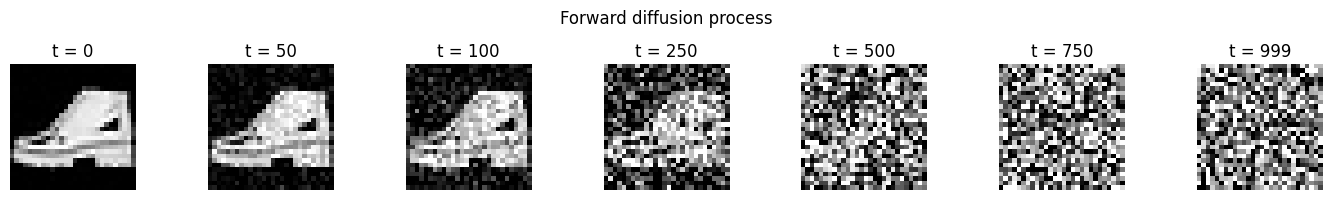

In [7]:
x0, _ = next(iter(train_loader))
x0 = x0[:1].to(device, non_blocking=True)  # (1, 1, 28, 28)

timesteps_to_show = torch.tensor([0, 50, 100, 250, 500, 750, 999], device = device, dtype = torch.long)
x0_batch = x0.expand(len(timesteps_to_show), -1, -1, -1)

with torch.no_grad():
    xt = q_sample(x0_batch, timesteps_to_show)

images = ((xt.clamp(-1, 1) + 1) * 0.5).cpu()

fig, axes = plt.subplots(1, len(timesteps_to_show), figsize=(14, 2))
for ax, img, t in zip(axes, images, timesteps_to_show.cpu()):
    ax.imshow(img[0].numpy(), cmap = "gray")
    ax.set_title(f"t = {t.item()}")
    ax.axis("off")

plt.suptitle("Forward diffusion process")
plt.tight_layout()
plt.show()

## 3. A small U-Net

The paper uses a U-Net with residual blocks, group norm, and self-attention at 16x16 resolution, with the timestep $t$ injected into every residual block via a sinusoidal position embedding (Appendix B).

For this version, we can accustomed to the requirement of 28x28, we use:
- A **sinusoidal time embedding** (the network needs to know *which* noise level it's looking at)
- A small number of **convolutional blocks** with GroupNorm + SiLU (Swish), downsampling then upsampling
- **Skip connections** between matching resolutions (that's the "U" in U-Net)

We drop self-attention at 28x28 with one channel it's not needed to get good results, and it keeps the code readable.

The network's job (Eq. 11, Algorithm 1): given a noisy image $\mathbf{x}_t$ and the timestep $t$, predict the noise $\epsilon$ that was added.


In [8]:
class SinusoidalPositionalEmbedding(nn.Module):
  """
  Try to remember the positional embeddings from Transformers
  """
  def __init__(self, dim):
    super().__init__()
    self.dim = dim

  def forward(self, t):
    half_dim = self.dim // 2
    freqs = torch.exp(-math.log(10000) * torch.arange(half_dim, device = t.device))
    args = t[:, None].float() * freqs[None, :]
    embedding = torch.cat([torch.sin(args), torch.cos(args)], dim = -1)
    return embedding

In [9]:
class ResidualBlock(nn.Module):
  """
  Convolutional block with GroupNorm + Swish function along with timestamp added (as a per-channel bias)
  """
  def __init__(self, in_ch, out_ch, time_emb_dim):
    super().__init__()
    self.time_mlp = nn.Linear(time_emb_dim, out_ch)

    # GroupNorm requires num_channels divisible by num_groups
    # The very first block sees 1-channel image, so fall back to group size that divides it.
    groups = 1 if in_ch < 8 else 8
    self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding = 1)
    self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding = 1)

    self.norm1 = nn.GroupNorm(groups, in_ch)
    self.norm2 = nn.GroupNorm(8, out_ch)

    self.act = nn.SiLU()
    self.residual_conv = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

  def forward(self, x, t_emb):
    h = self.conv1(self.act(self.norm1(x)))
    time_bias = self.time_mlp(self.act(t_emb))
    h = h + time_bias[:, :, None, None]
    h = self.conv2(self.act(self.norm2(h)))
    return h + self.residual_conv(x)

## Putting the U-Net together

Down path shrinks 28 -> 14 -> 7, bottleneck processes the 7x7 features, then the up
path grows back 7 -> 14 -> 28, concatenating the matching skip connection at each
resolution before reducing channels back down.

We use `F.interpolate` (nearest
neighbor) for upsampling, which is simpler than transposed convolutions and avoids any
size-mismatch headaches.


In [10]:
class SimpleUNet(nn.Module):
  """
  A small U-Net
  Down -> Bottleneck -> Up with skip connections
  Predicts noise epsilon added to x_t (Eq. 11)
  """
  def __init__(self, in_ch = 1, base_ch = 32, time_emb_dim = 128):
    super().__init__()
    self.time_mlp = nn.Sequential(
        SinusoidalPositionalEmbedding(time_emb_dim),
        nn.Linear(time_emb_dim, time_emb_dim),
        nn.SiLU(),
        nn.Linear(time_emb_dim, time_emb_dim),
    )

    # Downsampling Path (Channels grow as resolution shrinks)
    self.down1 = ResidualBlock(in_ch, base_ch, time_emb_dim) # 1 -> 32
    self.down2 = ResidualBlock(base_ch, base_ch * 2, time_emb_dim) # 32 -> 64
    self.down3 = ResidualBlock(base_ch * 2, base_ch * 4, time_emb_dim) # 64 -> 128
    self.pool = nn.AvgPool2d(2)

    self.bottleneck = ResidualBlock(base_ch * 4, base_ch * 4, time_emb_dim) # 128 -> 128

    # Upsampling Path (Concatenate skip connection, then reduce channels)
    self.up3 = ResidualBlock(base_ch * 8, base_ch * 2, time_emb_dim) # (128 from b_up + 128 from d3) -> 64
    self.up2 = ResidualBlock(base_ch * 4, base_ch, time_emb_dim) # (64 from u3_up + 64 from d2) -> 32

    self.out_conv = nn.Conv2d(base_ch * 2, in_ch, 1) # (32 from u2_up + 32 from d1) -> 1

  def forward(self, x, t):
    t_emb = self.time_mlp(t)

    # Down
    d1 = self.down1(x, t_emb)
    d2 = self.down2(self.pool(d1), t_emb)
    d3 = self.down3(self.pool(d2), t_emb)

    # Bottleneck
    b = self.bottleneck(self.pool(d3), t_emb)

    # Upsample with nearest-neighbor + resize to match
    b_up = F.interpolate(b, size = d3.shape[-2:], mode = "nearest")
    u3 = self.up3(torch.cat([b_up, d3], dim = 1), t_emb)

    u3_up = F.interpolate(u3, size = d2.shape[-2:], mode = "nearest")
    u2 = self.up2(torch.cat([u3_up, d2], dim = 1), t_emb)

    u2_up = F.interpolate(u2, size = d1.shape[-2:], mode = "nearest")
    out = self.out_conv(torch.cat([u2_up, d1], dim = 1))
    return out

In [11]:
model = SimpleUNet().to(device)
test_x = torch.randn(4, 1, 28, 28, device = device)
test_t = torch.randint(0, T, (4, ), device = device)
test_out = model(test_x, test_t)

print("Output Shape: ", test_out.shape)
print("Num Params: ", sum(p.numel() for p in model.parameters()))

Output Shape:  torch.Size([4, 1, 28, 28])
Num Params:  936259



## 4. Training objective: Algorithm 1

From the paper, the simplified objective (Eq. 14):

$$L_{simple}(\theta) := \mathbb{E}_{t, \mathbf{x}_0, \epsilon}\left[ \| \epsilon - \epsilon_\theta(\sqrt{\bar\alpha_t}\mathbf{x}_0 + \sqrt{1-\bar\alpha_t}\,\epsilon,\ t) \|^2 \right]$$

And **Algorithm 1 (Training)**, exactly:
```
repeat
    x0 ~ q(x0)                              # sample real image
    t ~ Uniform({1, ..., T})                # sample random timestep
    eps ~ N(0, I)                           # sample noise
    take gradient step on
        grad_theta || eps - eps_theta(sqrt(alpha_bar_t) x0 + sqrt(1-alpha_bar_t) eps, t) ||^2
until converged
```

In a nutshell, **corrupt a real image with a random amount of noise, and train the
network to predict exactly that noise.**


In [12]:
def training_loss(model, x0):
    batch_size = x0.shape[0]
    t = torch.randint(0, T, (batch_size,), device = x0.device).long()

    noise = torch.randn_like(x0)
    x_noisy = q_sample(x0, t, noise = noise)
    predicted_noise = model(x_noisy, t)
    return F.mse_loss(predicted_noise, noise)

## 5. Training loop

We train for a modest number of epochs, clearly enough on Fashion-MNIST to see
clearly recognizable clothing shapes emerge (not photorealistic, but clearly working).


Epoch 1 / 100 - Loss: 0.1638
Epoch 2 / 100 - Loss: 0.1156
Epoch 3 / 100 - Loss: 0.1056
Epoch 4 / 100 - Loss: 0.0997
Epoch 5 / 100 - Loss: 0.0938
Epoch 6 / 100 - Loss: 0.0889
Epoch 7 / 100 - Loss: 0.0869
Epoch 8 / 100 - Loss: 0.0817
Epoch 9 / 100 - Loss: 0.0774
Epoch 10 / 100 - Loss: 0.0746
Epoch 11 / 100 - Loss: 0.0734
Epoch 12 / 100 - Loss: 0.0708
Epoch 13 / 100 - Loss: 0.0717
Epoch 14 / 100 - Loss: 0.0700
Epoch 15 / 100 - Loss: 0.0696
Epoch 16 / 100 - Loss: 0.0695
Epoch 17 / 100 - Loss: 0.0678
Epoch 18 / 100 - Loss: 0.0682
Epoch 19 / 100 - Loss: 0.0668
Epoch 20 / 100 - Loss: 0.0662
Epoch 21 / 100 - Loss: 0.0661
Epoch 22 / 100 - Loss: 0.0643
Epoch 23 / 100 - Loss: 0.0652
Epoch 24 / 100 - Loss: 0.0644
Epoch 25 / 100 - Loss: 0.0636
Epoch 26 / 100 - Loss: 0.0638
Epoch 27 / 100 - Loss: 0.0644
Epoch 28 / 100 - Loss: 0.0632
Epoch 29 / 100 - Loss: 0.0637
Epoch 30 / 100 - Loss: 0.0624
Epoch 31 / 100 - Loss: 0.0624
Epoch 32 / 100 - Loss: 0.0629
Epoch 33 / 100 - Loss: 0.0637
Epoch 34 / 100 - Lo

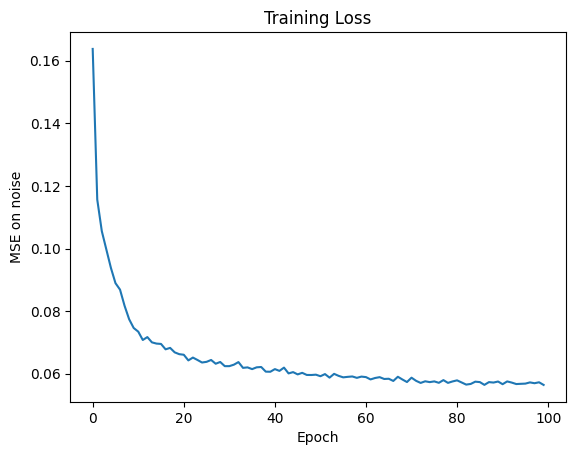

In [17]:
model = SimpleUNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr = 2e-4)

EPOCHS = 100 # Change if you need

losses = []
for epoch in range(EPOCHS):
  epoch_losses = []
  for step, (x0, _) in enumerate(train_loader):
    x0 = x0.to(device)
    optimizer.zero_grad()
    loss = training_loss(model, x0)
    loss.backward()
    optimizer.step()
    epoch_losses.append(loss.item())
  avg_loss = np.mean(epoch_losses)
  losses.append(avg_loss)
  print(f"Epoch {epoch + 1} / {EPOCHS} - Loss: {avg_loss:.4f}")

plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("MSE on noise")
plt.title("Training Loss")
plt.show()

## 6. Sampling: Algorithm 2

Once the model can predict noise well, we generate new images by running the reverse
process:
- start from pure noise $\mathbf{x}_T \sim \mathcal{N}(0, I)$, and repeatedly
denoise one step at a time down to $\mathbf{x}_0$.

**Algorithm 2 (Sampling)**, exactly:
```
x_T ~ N(0, I)
for t = T, ..., 1:
    z ~ N(0, I) if t > 1, else z = 0
    x_{t-1} = 1/sqrt(alpha_t) * (x_t - (beta_t / sqrt(1-alpha_bar_t)) * eps_theta(x_t, t)) + sigma_t * z
return x_0
```

We use $\sigma_t^2 = \beta_t$ (one of the two choices the paper found worked about
equally well, Section 3.2)

In [18]:
@torch.no_grad()
def sample(model, n_samples = 16, img_size = 28, channels = 1, return_intermediate = None):
  model.eval()
  x = torch.randn(n_samples, channels, img_size, img_size, device = device)
  intermediates = []
  for t_val in reversed(range(T)):
    t = torch.full((n_samples, ), t_val, device = device, dtype = torch.long)
    beta_t = extract(betas, t, x.shape)
    alpha_t = extract(alphas, t, x.shape)
    sqrt_one_minus_ac_t = extract(sqrt_one_minus_alphas_cumprod, t, x.shape)
    predicted_noise = model(x, t)

    mean = (1 / torch.sqrt(alpha_t)) * (x - (beta_t / sqrt_one_minus_ac_t) * predicted_noise)
    if t_val > 0:
      z = torch.randn_like(x)
      sigma_t = torch.sqrt(beta_t)
      x = mean + sigma_t * z
    else:
      x = mean

    if return_intermediate is not None and t_val % return_intermediate == 0:
      intermediates.append(x.clone().cpu())
  model.train()

  if return_intermediate is not None:
    return x, intermediates
  return x

### Now, let's generate new (obviously fake) Fashion-MNIST images

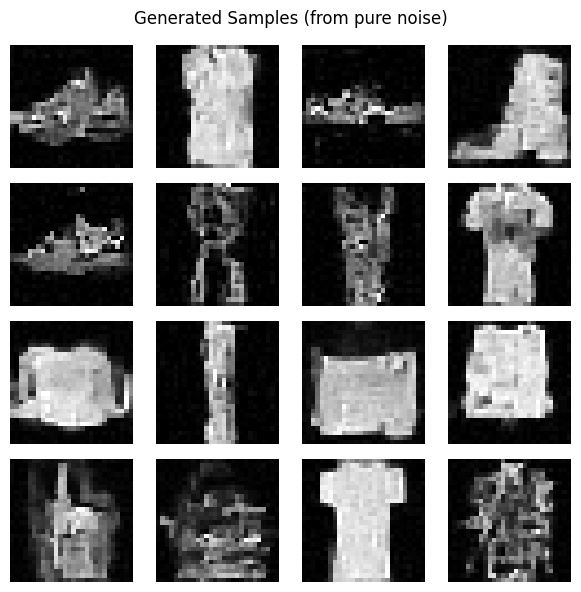

In [19]:
generated = sample(model, n_samples = 16)
generated = generated.cpu()
generated = (generated + 1) / 2
generated = generated.clamp(0, 1)

fig, axes = plt.subplots(4, 4, figsize = (6, 6))
for i, ax in enumerate(axes.flat):
  ax.imshow(generated[i, 0], cmap = "gray")
  ax.axis("off")
plt.suptitle("Generated Samples (from pure noise)")
plt.tight_layout()
plt.show()

## 7. Progressive generation (Section 4.3, Figure 6)

The paper shows that samples are built up **coarse-to-fine**: large-scale shape
appears first, fine detail appears last.

Let's reproduce that visualization for one
sample, showing $\hat{\mathbf{x}}_0$-like estimates at different points in the reverse
process.


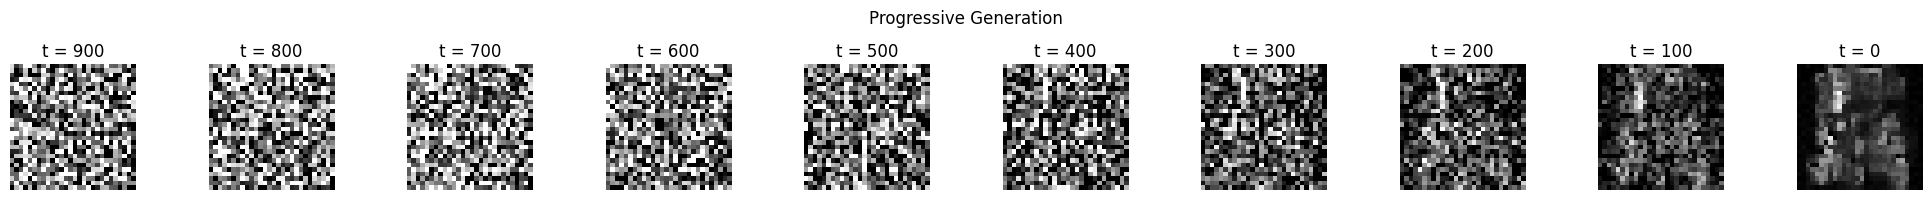

In [20]:
final_sample, intermediates = sample(model, n_samples = 1, return_intermediate = 100)
intermediates = [((img + 1) / 2).clamp(0, 1) for img in intermediates]

fig, axes = plt.subplots(1, len(intermediates), figsize = (2 * len(intermediates), 2))
for ax, img, t_val in zip(axes, intermediates, reversed(range(0, T, 100))):
  ax.imshow(img[0, 0], cmap = "gray")
  ax.set_title(f"t = {t_val}")
  ax.axis("off")

plt.suptitle("Progressive Generation")
plt.tight_layout()
plt.show()

## What to try next?
Things you could try, each tying back
to a specific part of the paper, to deepen understanding:

- **Increase `EPOCHS`** and/or `base_ch` in `SimpleUNet`: samples get noticeably
  better with more training / capacity.
- **Try $\sigma_t^2 = \tilde\beta_t$** instead of $\beta_t$ (Section 3.2 mentions both were tried and gave similar results).
- **Try predicting $\tilde\mu_t$ directly instead of $\epsilon$** (the "baseline"
  parameterization the paper compares against in Table 2) and see if training is
  less stable, as the paper reports.
- **Move to CIFAR-10**: you'll likely need a bigger U-Net and self-attention at
  16x16 (Section 4, Appendix B) to get good color-image results.
- **Try fewer diffusion steps** (e.g. `T = 200`): sampling is much faster, and you
  can see how sample quality degrades (this is the speed/quality tradeoff the paper
  mentions in Section 4).
